In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [2]:
df=pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head(1)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers


In [3]:
# Generating a crosstab for 'category' and 'isBestSeller'
cross = pd.crosstab(df['category'], df['isBestSeller']).sort_values(True, ascending=False)
cross

isBestSeller,False,True
category,,
Grocery,9008,556
Health & Personal Care,9017,552
Baby,14709,341
Sports & Outdoors,835935,330
Power & Hand Tools,8353,306
...,...,...
Downhill Ski Boots,1284,0
Digital Frames,774,0
Motorbike Chassis,107,0


In [4]:
cross_p= pd.crosstab(df['category'], df['isBestSeller'], normalize='index')
cross_p

isBestSeller,False,True
category,,
3D Printers,0.995968,0.004032
3D Printing & Scanning,0.999508,0.000492
Abrasive & Finishing Products,0.980000,0.020000
Action Cameras,0.999411,0.000589
Adapters,0.988189,0.011811
...,...,...
Wind Instruments,0.972000,0.028000
Window Treatments,0.979079,0.020921
Women,0.988015,0.011985


In [5]:
cross.index[:10]

Index(['Grocery', 'Health & Personal Care', 'Baby', 'Sports & Outdoors',
       'Power & Hand Tools', 'Beauty', 'Pet Supplies', 'Arts & Crafts',
       'Women', 'Men'],
      dtype='object', name='category')

In [6]:
from scipy.stats import chi2_contingency

# Chi-square test for 'category' and 'isBestSeller' dof = (#rows -1 ) * (#cols -1)
chi2_statistic, chi2_p_value, _, expected_freq = chi2_contingency(cross)

chi2_statistic, chi2_p_value

(np.float64(36540.202700613874), np.float64(0.0))

In [7]:
from scipy.stats.contingency import association

# Computing the association between variables in 'cross' using the "cramer" method
association(cross, method="cramer")

0.12228294397605641

<Axes: xlabel='category'>

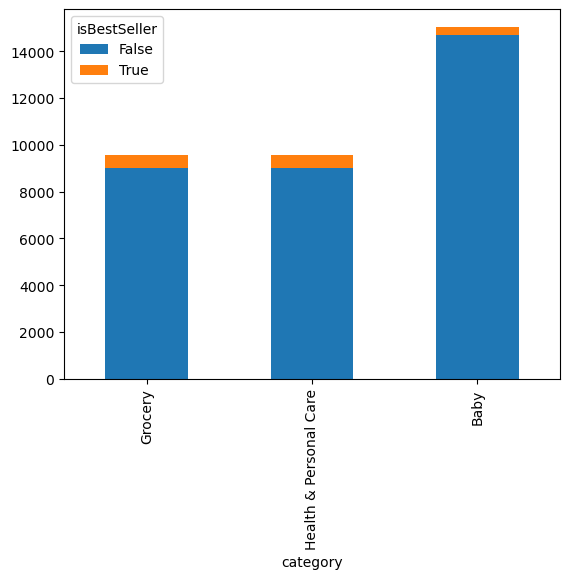

In [8]:
#plotting stacked bar chart for 'cross' data which contains the categories and best-seller status
#As there are so many categories we will only look at the top ones.
cross.iloc[:3].plot(kind='bar',stacked=True)

<Axes: xlabel='category'>

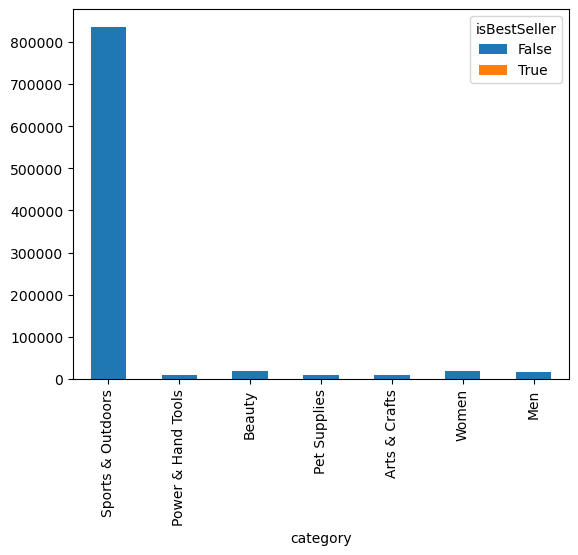

In [9]:
#now with Sports & Outdoors 
cross.iloc[3:10].plot(kind='bar',stacked=True)

In [10]:
df.head(1)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers


In [11]:
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define wiskers for the outliers
    lower_wisker = Q1 - 1.5 * IQR
    upper_wisker = Q3 + 1.5 * IQR

    # Identify the outliers
    outliers = data[(data < lower_wisker) | (data > upper_wisker)]

    return outliers

In [12]:
col_data = df['price']  
outliers = tukeys_test_outliers(col_data)
print(outliers)


10         139.00
19         164.99
25         149.99
28         289.00
31         199.99
            ...  
2443619    166.99
2443627    152.58
2443638    108.77
2443641    166.99
2443643    158.99
Name: price, Length: 327688, dtype: float64


In [13]:
#Creating a new data frame df1 without the ouliers in price column.
df1= df.iloc[~outliers.index,:]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 327688 entries, 2443640 to 7
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   uid                327688 non-null  int64  
 1   asin               327688 non-null  object 
 2   title              327688 non-null  object 
 3   stars              327688 non-null  float64
 4   reviews            327688 non-null  int64  
 5   price              327688 non-null  float64
 6   isBestSeller       327688 non-null  bool   
 7   boughtInLastMonth  327688 non-null  int64  
 8   category           327688 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 22.8+ MB


In [14]:
df1.category.value_counts().sort_values(ascending=False)

category
Sports & Outdoors                         129862
Bath & Body                                 9548
Camera & Photo Accessories                  7118
Handmade Clothing, Shoes & Accessories      6487
Fragrances                                  6238
                                           ...  
Professional Medical Supplies                  1
USB Hubs                                       1
Women's Sports & Outdoor Shoes                 1
Art & Craft Supplies                           1
eBook Readers & Accessories                    1
Name: count, Length: 283, dtype: int64

In [15]:
cat_10=df1.category.value_counts().sort_values(ascending=False).index[:10].tolist()
cat_p1=df1[df.category.isin(cat_10)]

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_26497/3356380563.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cat_p1=df1[df.category.isin(cat_10)]


/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_26497/1216195352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cat_p1, x='category', y='price', palette="coolwarm", legend=False)


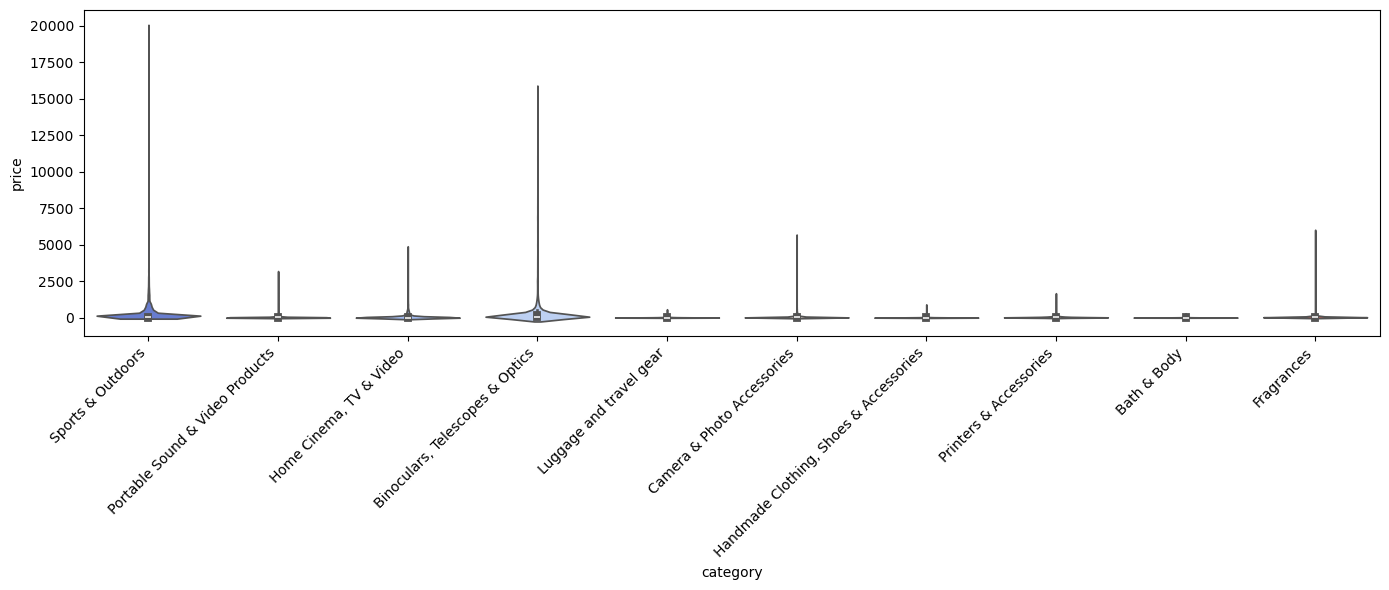

In [19]:
# Plotting a violin plot to visualize the distribution of 'price' for each 'category', using the "coolwarm" color palette

plt.figure(figsize=(14, 6))
sns.violinplot(data=cat_p1, x='category', y='price', palette="coolwarm", legend=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [17]:
cat_20=df1.category.value_counts().sort_values(ascending=False).index[10:21].tolist()
cat_p2=df1[df1.category.isin(cat_20)]

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_26497/129906675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cat_p2, x='category', y='price', palette="coolwarm", legend=False);


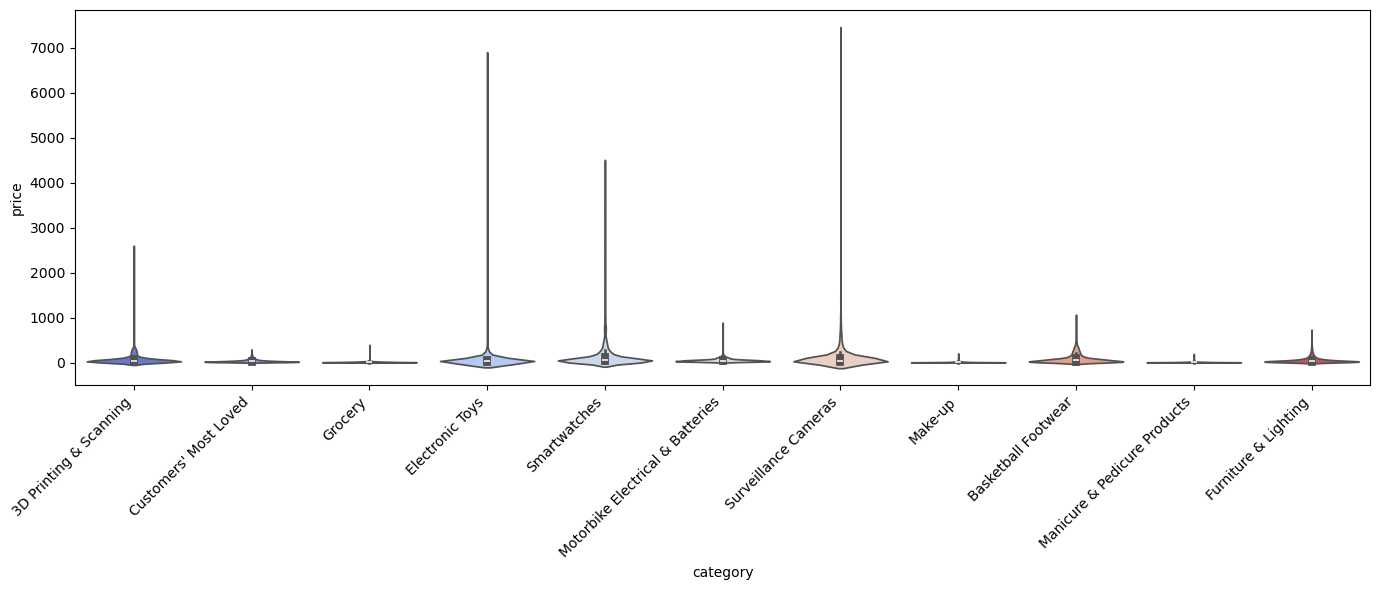

In [20]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=cat_p2, x='category', y='price', palette="coolwarm", legend=False);
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
df1.groupby('category')['price'].agg('median').sort_values(ascending=False)[:11]


category
Digital Cameras                        1524.000
Professional Medical Supplies          1305.160
Desktop PCs                             674.990
Laptops                                 566.990
Barebone PCs                            532.990
Wind Instruments                        449.730
Home Audio Record Players               408.130
Snowboard Boots                         399.135
Motorbike Exhaust & Exhaust Systems     306.300
Lenses                                  299.000
PA & Stage                              290.590
Name: price, dtype: float64

In [38]:
top_cat_count = df['category'].value_counts().to_frame()
top_10_cats= top_cat_count.head(10).index
top_10_cats

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances'],
      dtype='object', name='category')

In [39]:
# Plotting a stacked bar chart for the 'crosstab_result' data
cat_avgprice = (
    df1[df1['category'].isin(top_10_cats)]
    .groupby('category')['price']
    .agg('mean')
    .sort_values(ascending=False)
    .to_frame()
)

cat_avgprice

,price
category,
Sports & Outdoors,98.561179
Fragrances,40.094859
"Handmade Clothing, Shoes & Accessories",20.474577
Birthday Gifts,19.149880
Beauty,16.882695
Skin Care,16.166716
Hair Care,14.590372
Bath & Body,14.448091
Make-up,10.699719


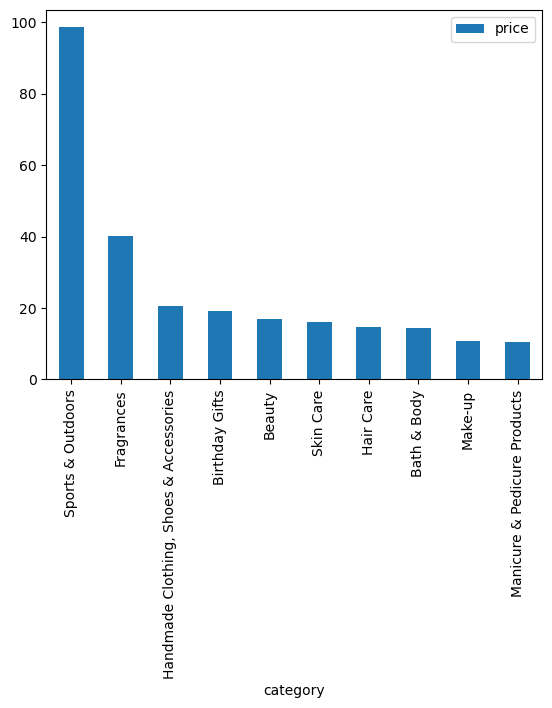

In [41]:
#average price for the top 10 categories by count.
cat_avgprice.plot(kind="bar", stacked=True);

In [ ]:
top_cat=df1.category.value_counts().sort_values(ascending=False)
top_cat.to_frame()

In [42]:
top_10_cats= top_cat_count.head(10).index
top_10_cats

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances'],
      dtype='object', name='category')

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_26497/1776014270.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)


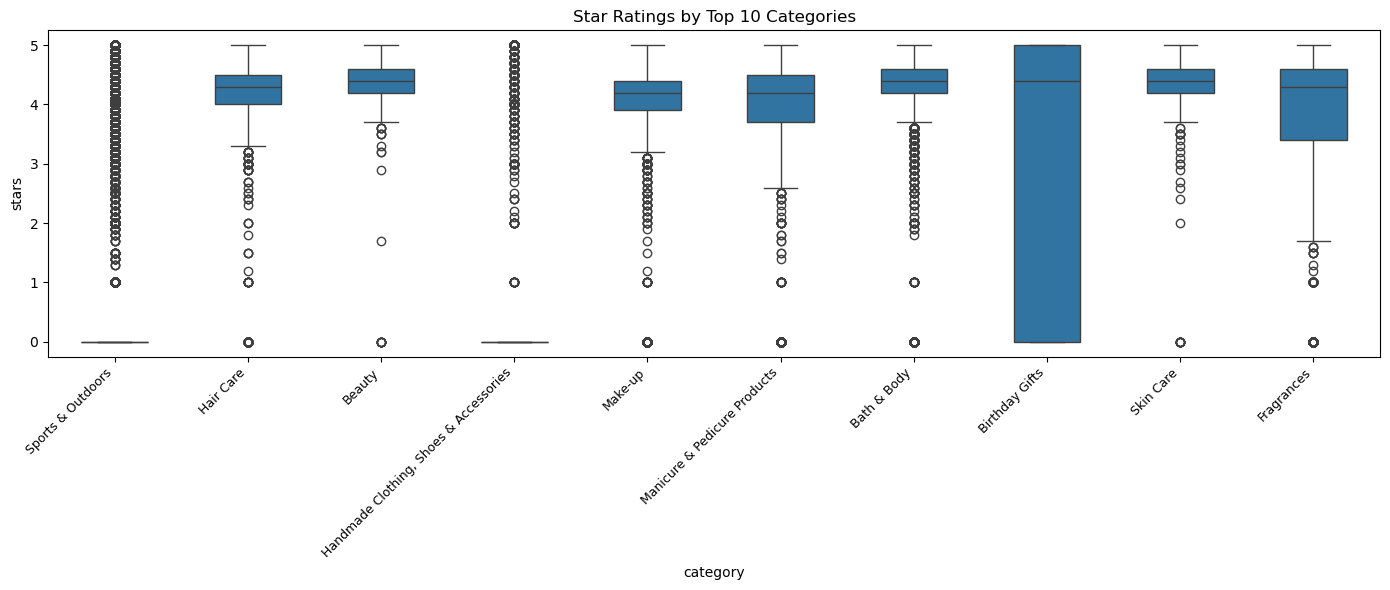

In [45]:
#Visualization

# 2.1 Plot a box plot for 'stars' which will be our product ratings indicator, categorized by 'category'.
# This will help visualize the central tendencies and spreads for each sale condition.
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df1[df1.category.isin(top_10_cats)],
    x='category', y='stars',
    width=0.5, ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_title('Star Ratings by Top 10 Categories')
plt.tight_layout()
plt.show()

In [46]:
# Calculating the Pearson correlation coefficients between 'price' and 'stars'

p_corr = df['price'].corr(df['stars'], method='pearson')
p_corrs = df['price'].corr(df['stars'], method='spearman')
round(p_corr,2),round(p_corrs,2)

(np.float64(-0.12), np.float64(-0.13))

In [ ]:
# Plotting a scatter plot to visualize the relationship between 'price' and 'stars'
sns.scatterplot(data=df, x='price', y='stars');

In [ ]:
Use a correlation heatmap to visualize correlations between all numerical variables.

In [ ]:
numerical = df.select_dtypes("number")
numerical.drop('uid',inplace=True,axis=1)
numerical

In [ ]:
correlation_matrix = numerical.corr()

# Setting up the matplotlib figure with an appropriate size
plt.figure(figsize=(7, 5))

# Drawing the heatmap for the numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

In [ ]:
import statsmodels.api as sm

# Generating a Q-Q plot for 'price' to check if its distribution follows a normal distribution
sm.qqplot(df['price'], line='s');

In [ ]:
#analysis without the outliers
num_out = df1.select_dtypes("number")
num_out.drop('uid',inplace=True,axis=1)
num_out

In [ ]:
#using the data frame without outliers
corr_out = num_out.corr()
# Plotting a scatter plot to visualize the relationship between 'price' and 'stars'
sns.scatterplot(data=df1, x='price', y='stars');
# Setting up the matplotlib figure with an appropriate size
plt.figure(figsize=(7, 5))

# Drawing the heatmap for the numerical columns
sns.heatmap(corr_out, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables - No outliers")
plt.show()
# Generating a Q-Q plot for 'price' to check if its distribution follows a normal distribution
sm.qqplot(df1['price'], line='s');